In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ResNet3D, ResNetBlock3D, GraphConvolution, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn

print(jax.default_backend())

cpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2"

# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0"


out_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    # i_snapshots=[-2,-1],
    i_snapshots=range(1, 33+4, 8),
    # i_snapshots=range(1, 33+4, 4),
    return_hydro=True,
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

No matching catalogs found, returning only the snapshots
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:05,  1.35s/it]

Found 368 duplicate gas particle IDs


finding unique gas particle indices:  40%|████      | 2/5 [00:07<00:11,  3.91s/it]

Found 4088 duplicate gas particle IDs


...

finding unique gas particle indices:  80%|████████  | 4/5 [00:18<00:04,  4.97s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 5/5 [00:23<00:00,  4.71s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [01:20<00:00, 16.02s/it]


In [5]:
with_latent = False

model = MLP(
    d_in=5 + with_latent, 
    d_out=1 + with_latent, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)
architecture = "mlp"

In [6]:
i = -1

scale = scales[i]
dm_pos = dm_poss[i]
gas_pos = gas_poss[i]
gas_vel = gas_vels[i]

In [7]:
from jaxpm.hpm import hpm_forces

hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model,
    # gas_latent=None,
    gravity_only=False,
    architecture="mlp",
)

TypeError: hpm_forces() got an unexpected keyword argument 'gravity_only'

In [9]:
from jaxpm.data import get_hpm_inputs

N_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

# assume identical mass for all particles [dm_mass particle] TODO
rho_dm = N_dm
rho_gas = N_gas * (cosmo.Omega_b / cosmo.Omega_c)

gas_rho = cic_read(rho_gas, gas_pos)

gas_inputs, field_inputs = get_hpm_inputs(
    scale,
    gas_pos,
    gas_vel,
    gas_rho,
    rho_gas,
    gas_N,
    mesh_shape,
    gas_latent=None,
    return_field=True,
)

In [12]:
field_inputs.shape

(64, 64, 64, 4)

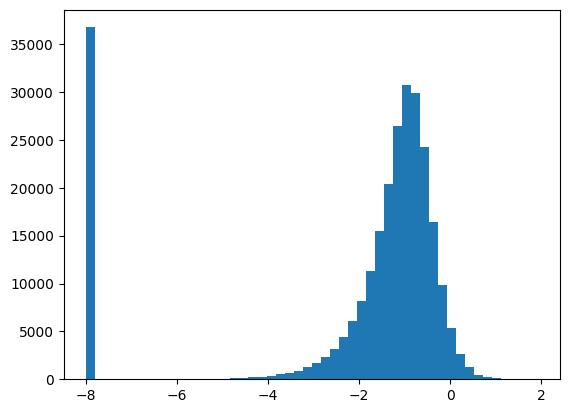

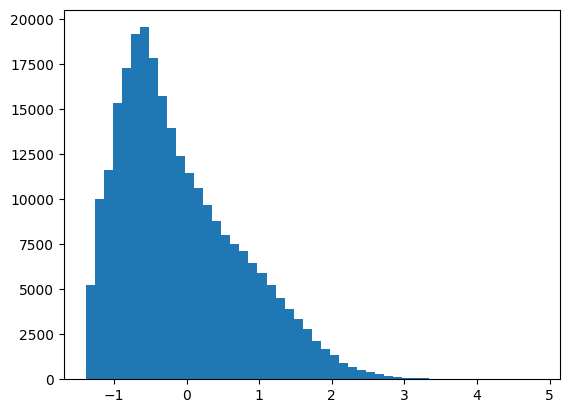

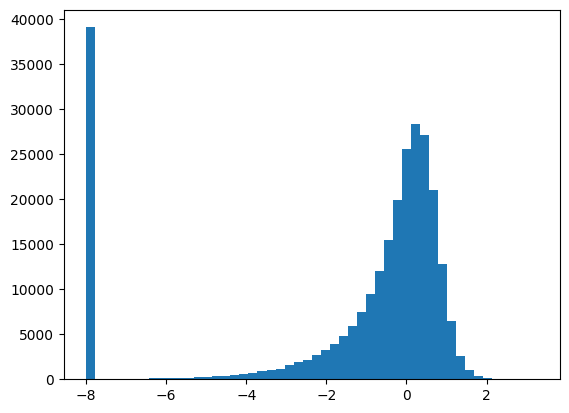

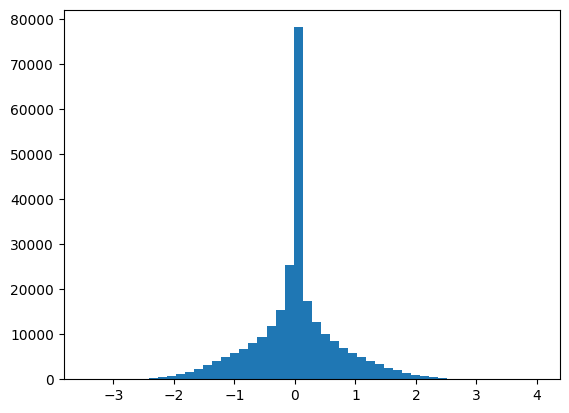

In [14]:
for i in range(field_inputs.shape[-1]):
    fig, ax = plt.subplots()
    ax.hist(field_inputs[...,i].ravel(), bins=50)

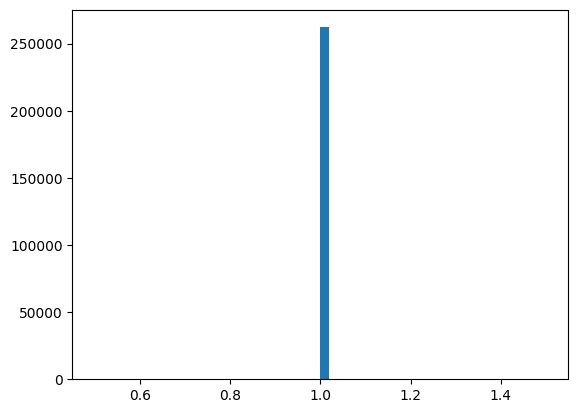

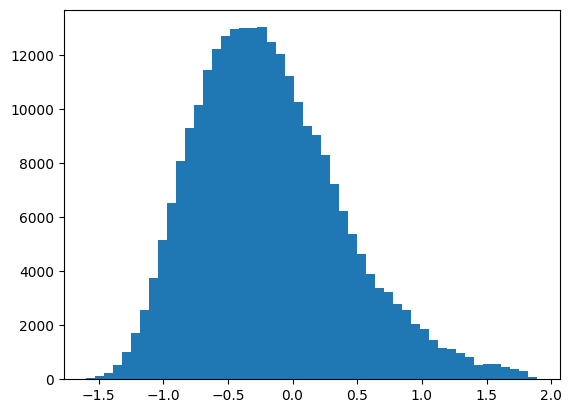

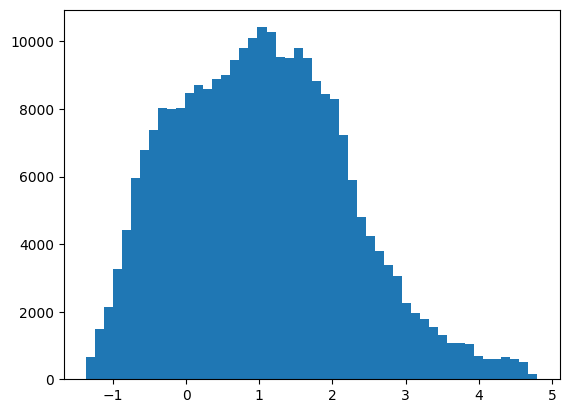

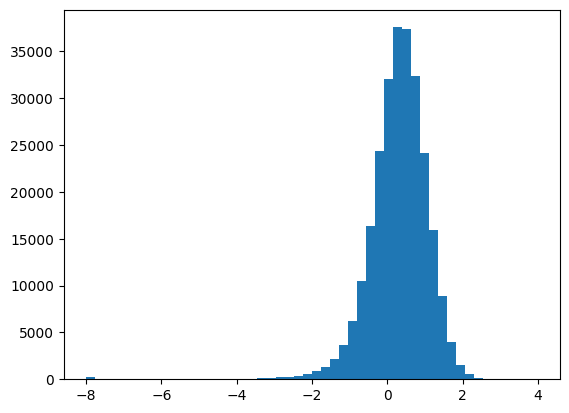

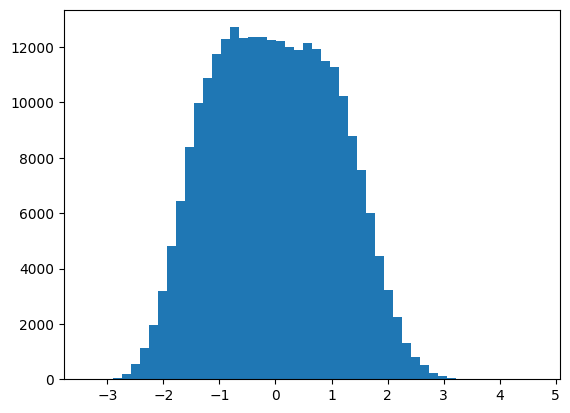

In [11]:
for i in range(gas_inputs.shape[-1]):
    fig, ax = plt.subplots()
    ax.hist(gas_inputs[:,i], bins=50)

In [ ]:
gas_inputs.shape

In [ ]:
jnp.sum(jnp.isnan(gas_inputs))

In [ ]:
jnp.sum(~jnp.isfinite(gas_inputs), axis=0)

# latent

In [13]:
from jaxpm.data import get_hpm_inputs

N_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

# assume identical mass for all particles [dm_mass particle] TODO
rho_dm = N_dm
rho_gas = N_gas * (cosmo.Omega_b / cosmo.Omega_c)

gas_rho = cic_read(rho_gas, gas_pos)

gas_inputs = get_hpm_inputs(
    scale,
    gas_pos,
    gas_vel,
    gas_rho,
    rho_gas,
    gas_N,
    mesh_shape,
    gas_latent=jnp.ones(parts_per_dim**3),
    return_field=False,
)

AssertionError: 

In [ ]:
gas_inputs

In [ ]:
from jaxpm.hpm import hpm_forces

with_latent = True
model = MLP(
    d_in=5 + with_latent, 
    d_out=1 + with_latent, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

dm_force, gas_force, gas_latent = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model,
    gas_latent=jnp.ones((parts_per_dim**3, 1)),
    gravity_only=False,
    architecture="mlp",
)

In [ ]:
from jaxpm.hpm import hpm_forces

with_latent = True

mlp = MLP(
    d_in=5 + with_latent,
    d_out=8, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

cnn = CNN(
    d_in=4 + with_latent,
    d_out=8,
    d_hidden=8,
    n_hidden=1,
    kernel_size=(3, 3, 3),
    strides=1,
    rngs=nnx.Rngs(0)
)

model = HybridNet(
    mlp,
    cnn,
    d_out=1 + with_latent,
    rngs=nnx.Rngs(0)
)

dm_force, gas_force, gas_latent = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model,
    gas_latent=jnp.ones((parts_per_dim**3, 1)),
    gravity_only=False,
    architecture="mlp+cnn",
)

In [ ]:
from jaxpm.hpm import hpm_forces

with_latent = False

model = AttentionGNN(
    d_node=5 + with_latent,
    d_edge=1,
    d_query=16,
    n_hidden=4,
    d_out=1 + with_latent,
    rngs=nnx.Rngs(0),
)

dm_force, gas_force, gas_latent = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model,
    # gas_latent=jnp.ones((parts_per_dim**3, 1)),
    gravity_only=False,
    architecture="gnn",
)

In [ ]:
edges["features"].shape

In [ ]:
edges["senders"].shape

In [ ]:
edges["receivers"].shape

In [ ]:
gas_inputs.shape

In [ ]:
scales

In [ ]:
from jaxpm.graph import get_graph_given_edges, get_edges

node_features = get_hpm_inputs(
    scale,
    gas_pos,
    gas_vel,
    gas_rho,
    rho_gas,
    gas_N,
    mesh_shape,
    gas_latent=jnp.ones(parts_per_dim**3),
    return_field=False,
)

edges = get_edges(gas_poss, scales, k=4, boxsize=None)

In [ ]:
get_graph_given_edges(node_features, edges, current_scale=0.5);

In [ ]:
get_graph_given_edges(node_features, edges, current_scale=0.9);

In [ ]:
get_graph_given_edges(node_features, edges, current_scale=0.0);

In [ ]:
node_features.shape

In [ ]:
from jaxpm.hpm import hpm_forces
from jaxpm.graph import get_edges

with_latent = False

model = AttentionGNN(
    d_node=5 + with_latent,
    d_edge=1,
    d_query=16,
    n_hidden=4,
    d_out=1 + with_latent,
    rngs=nnx.Rngs(0),
)

edges = get_edges(gas_poss, scales, k=4, boxsize=None)

dm_force, gas_force, gas_latent = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model,
    edges=edges,
    # gas_latent=jnp.ones((parts_per_dim**3, 1)),
    gravity_only=False,
    architecture="gnn",
)

In [ ]:
edges

In [ ]:
from jaxpm.hpm import get_hpm_network_ode_fn

with_latent = True
model = MLP(
    d_in=5 + 2*with_latent, 
    d_out=1 + with_latent, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, gravity_only=False, integrator_type="diffrax")

dm_force, gas_force, gas_latent = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model,
    # gas_latent=jnp.ones((parts_per_dim**3, 1)),
    gas_latent=jnp.ones((parts_per_dim**3)),
    gravity_only=False,
    architecture="mlp",
)

In [ ]:
i = -1
d_dm_pos, d_dm_vel, d_gas_pos, d_gas_vel, d_gas_latent = hpm_ode(
    scales[i], 
    # (dm_poss[i], dm_vels[i], gas_poss[i], gas_vels[i]), 
    # (dm_poss[i], dm_vels[i], gas_poss[i], gas_vels[i], jnp.ones((parts_per_dim**3, 1))), 
    (dm_poss[i], dm_vels[i], gas_poss[i], gas_vels[i], jnp.ones((parts_per_dim**3))), 
    None
)

In [ ]:
d_gas_latent.shape

In [ ]:
d_gas_latent.shape

In [ ]:
d_dm_pos.shape

In [ ]:
d_dm_vel.shape

In [ ]:
d_gas_pos.shape

In [ ]:
d_gas_vel.shape

In [ ]:
from jaxpm.painting import cic_paint, cic_read
from jaxpm.kernels import invlaplace_kernel

In [ ]:
gas_pos

In [28]:
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

# gas_latent = np.random.random((parts_per_dim**3))
gas_latent = gas_N
latent_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, gas_latent/gas_N)

latent_gas_k = jnp.fft.rfftn(latent_gas)
kvec = fftk(mesh_shape)
# latent_kernel_gas_k = latent_gas_k * invnabla_kernel(kvec)
latent_kernel_gas_k = latent_gas_k * invlaplace_kernel(kvec)
latent_kernel_gas = jnp.fft.irfftn(latent_kernel_gas_k)
gas_latent_kernel = cic_read(latent_kernel_gas, gas_pos)

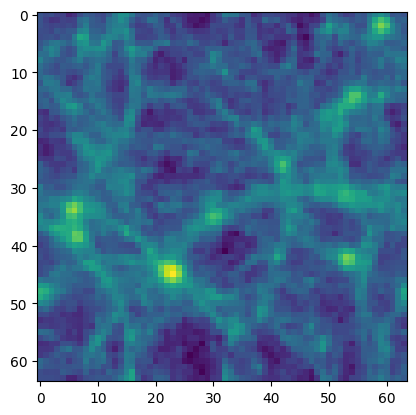

In [29]:
fig, ax = plt.subplots()

ax.imshow(jnp.log10(jnp.sum(N_gas, axis=0)))

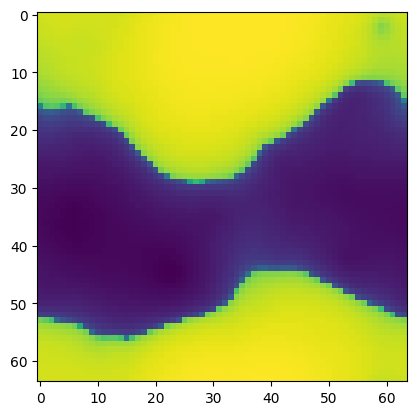

In [30]:
fig, ax = plt.subplots()

ax.imshow(jnp.arcsinh(jnp.sum(latent_kernel_gas, axis=0)))

In [16]:
gas_latent_kernel.shape

(262144,)

In [ ]:
gas_latent_kernel.shape

In [ ]:
latent_gas_kernel.shape

In [ ]:
latent_gas